In [5]:
# Connecting to MongoDB

from pyspark.sql import SparkSession

# Creating Spark Session
spark = SparkSession.builder \
    .appName("PlaystoreAnalysis") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .getOrCreate()


In [6]:

# Reading the data from MondoDB
df = spark.read.format("mongodb") \
    .option("database", "playstore") \
    .option("collection", "apps") \
    .load()

# Confirming if the data reading succeeded
df.printSchema()
df.show()

root
 |-- _id: string (nullable = true)
 |-- app_development: struct (nullable = true)
 |    |-- released: timestamp (nullable = true)
 |    |-- last_updated: timestamp (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- details: struct (nullable = true)
 |    |-- size_mb: double (nullable = true)
 |    |-- min_android: string (nullable = true)
 |    |-- content_rating: string (nullable = true)
 |-- developer_id: string (nullable = true)
 |-- features: struct (nullable = true)
 |    |-- ads_supported: boolean (nullable = true)
 |    |-- in_app_purchases: boolean (nullable = true)
 |    |-- editors_choice: boolean (nullable = true)
 |-- popularity_metrics: struct (nullable = true)
 |    |-- rating: double (nullable = true)
 |    |-- rating_count: integer (nullable = true)
 |    |-- installs: long (nullable = true)
 |    |-- min_installs: long (nullable = true)
 |    |-- max_installs: long (nullable 

## Data Analysis and Visualization

### Dependency analysis of apps ratings and price type

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, stddev, count, min, max,when, round as spark_round, expr
import pandas as pd
import matplotlib.pyplot as plt



# Create temp view for SQL queries
df.createOrReplaceTempView("apps")

# ============================================================
# ANALYSIS 1: BASIC STATISTICS - FREE VS PAID RATINGS
# ============================================================

# print("\n" + "="*60)
# print("RATING STATISTICS: FREE VS PAID APPS")
# print("="*60)

# First, let's check what column names we actually have
# rint("Available columns:", df.columns)


# rating_stats = spark.sql("""
#     SELECT 
#         CASE WHEN free = true THEN 'Free' ELSE 'Paid' END AS price_type,
#         COUNT(*) AS total_apps_with_ratings,
#         ROUND(AVG(rating), 2) AS avg_rating,
#         ROUND(STDDEV(rating), 2) AS stddev_rating,
#         ROUND(MIN(rating), 2) AS min_rating,
#         ROUND(MAX(rating), 2) AS max_rating,
#         ROUND(PERCENTILE_APPROX(rating, 0.5), 2) AS median_rating
#     FROM apps
#     WHERE rating IS NOT NULL AND rating > 0
#     GROUP BY free
# """)

# rating_stats.show(truncate=False)


print("="*60)
print("RATING STATISTICS: FREE VS PAID APPS - USING DATAFRAME API")
print("="*60)

# Filter and create price_type column, then aggregate
rating_stats_df = (df
    .filter(col("rating").isNotNull() & (col("rating") > 0))
    .withColumn("price_type", when(col("Free") == True, "Free").otherwise("Paid"))
    .groupBy("price_type")
    .agg(
        count("*").alias("total_apps_with_ratings"),
        spark_round(avg("rating"), 2).alias("avg_rating"),
        spark_round(stddev("rating"), 2).alias("stddev_rating"),
        spark_round(min("rating"), 2).alias("min_rating"),
        spark_round(max("rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(rating, 0.5)"), 2).alias("median_rating")
    )
)

# ACTION - triggers computation
rating_stats_df.show(truncate=False)


# ============================================================
# ANALYSIS 2: RATING DISTRIBUTION BY PRICE TYPE
# ============================================================

print("\n" + "="*60)
print("RATING DISTRIBUTION: FREE VS PAID")
print("="*60)

rating_distribution = spark.sql("""
    SELECT 
        CASE WHEN free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        CASE 
            WHEN rating >= 4.5 THEN '4.5 - 5.0 (Excellent)'
            WHEN rating >= 4.0 THEN '4.0 - 4.5 (Good)'
            WHEN rating >= 3.5 THEN '3.5 - 4.0 (Average)'
            WHEN rating >= 3.0 THEN '3.0 - 3.5 (Below Average)'
            WHEN rating >= 2.0 THEN '2.0 - 3.0 (Poor)'
            ELSE 'Below 2.0 (Very Poor)'
        END AS rating_category,
        COUNT(*) AS app_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY free), 2) AS percentage
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY free, rating_category
    ORDER BY free DESC, rating_category
""")

rating_distribution.show(20, truncate=False)

# ============================================================
# ANALYSIS 3: STATISTICAL SIGNIFICANCE
# ============================================================

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*60)

significance = spark.sql("""
    WITH stats AS (
        SELECT 
            free,
            COUNT(*) AS n,
            AVG(rating) AS mean,
            STDDEV(rating) AS stddev,
            VARIANCE(rating) AS variance
        FROM apps
        WHERE rating IS NOT NULL AND rating > 0
        GROUP BY free
    )
    SELECT 
        MAX(CASE WHEN free = true THEN mean END) AS free_mean,
        MAX(CASE WHEN free = false THEN mean END) AS paid_mean,
        MAX(CASE WHEN free = true THEN stddev END) AS free_stddev,
        MAX(CASE WHEN free = false THEN stddev END) AS paid_stddev,
        MAX(CASE WHEN free = true THEN n END) AS free_n,
        MAX(CASE WHEN free = false THEN n END) AS paid_n,
        ABS(MAX(CASE WHEN free = true THEN mean END) - MAX(CASE WHEN free = false THEN mean END)) AS mean_difference
    FROM stats
""").collect()[0]

print(f"Free apps average rating: {significance['free_mean']:.2f}")
print(f"Paid apps average rating: {significance['paid_mean']:.2f}")
print(f"Difference: {significance['mean_difference']:.2f}")

# Calculate effect size (Cohen's d approximation)
pooled_std = ((significance['free_stddev']**2 + significance['paid_stddev']**2) / 2) ** 0.5
effect_size = significance['mean_difference'] / pooled_std

print(f"\nEffect size (Cohen's d): {effect_size:.3f}")
if abs(effect_size) < 0.2:
    print("Interpretation: Negligible effect")
elif abs(effect_size) < 0.5:
    print("Interpretation: Small effect")
elif abs(effect_size) < 0.8:
    print("Interpretation: Medium effect")
else:
    print("Interpretation: Large effect")

# ============================================================
# ANALYSIS 4: TOP RATED APPS BY PRICE TYPE
# ============================================================

print("\n" + "="*60)
print("TOP 5 HIGHEST RATED FREE APPS")
print("="*60)

top_free = spark.sql("""
    SELECT 
        app_name,
        category,
        ROUND(rating, 2) AS rating,
        rating_count AS review_count
    FROM apps
    WHERE free = true 
        AND rating IS NOT NULL 
        AND rating > 0
    ORDER BY rating DESC
    LIMIT 5
""")
top_free.show(truncate=False)

print("\n" + "="*60)
print("TOP 5 HIGHEST RATED PAID APPS")
print("="*60)

top_paid = spark.sql("""
    SELECT 
        app_name,
        category,
        ROUND(rating, 2) AS rating,
        rating_count AS review_count,
        CONCAT('$', price) AS price
    FROM apps
    WHERE free = false 
        AND rating IS NOT NULL 
        AND rating > 0
    ORDER BY rating DESC
    LIMIT 5
""")
top_paid.show(truncate=False)

# ============================================================
# ANALYSIS 5: SUMMARY AND CONCLUSION
# ============================================================

print("\n" + "="*60)
print("SUMMARY AND CONCLUSIONS")
print("="*60)

summary = spark.sql("""
    SELECT 
        CASE WHEN free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        COUNT(*) AS total_apps_with_real_ratings,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(PERCENTILE_APPROX(rating, 0.5), 2) AS median_rating,
        ROUND(STDDEV(rating), 3) AS rating_stddev,
        COUNT(CASE WHEN rating >= 4.0 THEN 1 END) AS high_rated_apps,
        ROUND(COUNT(CASE WHEN rating >= 4.0 THEN 1 END) * 100.0 / COUNT(*), 1) AS pct_high_rated
    FROM apps
    WHERE rating IS NOT NULL AND rating > 0
    GROUP BY free
""")

summary.show(truncate=False)

# Statistical conclusion
results = summary.collect()
free_avg = [row['avg_rating'] for row in results if row['price_type'] == 'Free'][0]
paid_avg = [row['avg_rating'] for row in results if row['price_type'] == 'Paid'][0]

print(f"\nKEY FINDINGS:")
print(f"• Free apps average rating: {free_avg:.2f}")
print(f"• Paid apps average rating: {paid_avg:.2f}")
print(f"• Difference: {abs(free_avg - paid_avg):.2f} points")
print(f"• Effect size (Cohen's d): {effect_size:.3f}")

if effect_size < 0.2:
    print("\n• CONCLUSION: NO meaningful dependency between rating and price type")
    print("  The rating difference is negligible - less than 0.2 standard deviations")
elif effect_size < 0.5:
    print("\n• CONCLUSION: Weak dependency - Paid apps tend to have slightly higher ratings")
elif effect_size < 0.8:
    print("\n• CONCLUSION: Moderate dependency - Paid apps have noticeably higher ratings")
else:
    print("\n• CONCLUSION: Strong dependency - Paid apps have substantially higher ratings")



RATING STATISTICS: FREE VS PAID APPS - USING DATAFRAME API
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|price_type|total_apps_with_ratings|avg_rating|stddev_rating|min_rating|max_rating|median_rating|
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|Free      |1202394                |4.1       |0.69         |1.0       |5.0       |4.2          |
|Paid      |25383                  |4.15      |0.62         |1.0       |5.0       |4.3          |
+----------+-----------------------+----------+-------------+----------+----------+-------------+


RATING DISTRIBUTION: FREE VS PAID
+----------+-------------------------+---------+----------+
|price_type|rating_category          |app_count|percentage|
+----------+-------------------------+---------+----------+
|Free      |2.0 - 3.0 (Poor)         |71698    |5.96      |
|Free      |3.0 - 3.5 (Below Average)|103777   |8.63      |
|Free      |3.5 -

### Performance test between DataFrame API vs Spark SQL

In [6]:
from pyspark.sql.functions import col, avg, stddev, count, min, max, when, round as spark_round, expr
import time

# ============================================================
# DataFrame API execution
# ============================================================
print("="*60)
print("DataFrame API Performance Test")
print("="*60)

start_df = time.time()

# Same filtering, aggregation, and metrics as SQL version
rating_stats_df = (df
    .filter(col("Rating").isNotNull() & (col("Rating") > 0))
    .withColumn("price_type", when(col("Free") == True, "Free").otherwise("Paid"))
    .groupBy("price_type")
    .agg(
        count("*").alias("total_apps_with_ratings"),
        spark_round(avg("Rating"), 2).alias("avg_rating"),
        spark_round(stddev("Rating"), 2).alias("stddev_rating"),
        spark_round(min("Rating"), 2).alias("min_rating"),
        spark_round(max("Rating"), 2).alias("max_rating"),
        spark_round(expr("percentile_approx(Rating, 0.5)"), 2).alias("median_rating")
    )
)

rating_stats_df.show(truncate=False)

df_time = time.time() - start_df
print(f"DataFrame API execution time: {df_time:.3f} seconds\n")

# ============================================================
# Spark SQL execution
# ============================================================
print("="*60)
print("Spark SQL Performance Test")
print("="*60)

# Create temp view
df.createOrReplaceTempView("apps")

start_sql = time.time()

# IDENTICAL query to DataFrame API
query = """
    SELECT 
        CASE WHEN Free = true THEN 'Free' ELSE 'Paid' END AS price_type,
        COUNT(*) AS total_apps_with_ratings,
        ROUND(AVG(Rating), 2) AS avg_rating,
        ROUND(STDDEV(Rating), 2) AS stddev_rating,
        ROUND(MIN(Rating), 2) AS min_rating,
        ROUND(MAX(Rating), 2) AS max_rating,
        ROUND(PERCENTILE_APPROX(Rating, 0.5), 2) AS median_rating
    FROM apps
    WHERE Rating IS NOT NULL AND Rating > 0
    GROUP BY Free
"""

result_sql = spark.sql(query)
result_sql.show(truncate=False)

sql_time = time.time() - start_sql
print(f"Spark SQL execution time: {sql_time:.3f} seconds\n")

# ============================================================
# PERFORMANCE COMPARISON SUMMARY
# ============================================================
print("="*60)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*60)
print(f"DataFrame API: {df_time:.3f} seconds")
print(f"Spark SQL:    {sql_time:.3f} seconds")
print(f"Difference:   {abs(df_time - sql_time):.3f} seconds")
if df_time < sql_time:
    print(f"DataFrame API was {(sql_time/df_time):.2f}x faster")
else:
    print(f"Spark SQL was {(df_time/sql_time):.2f}x faster")


DataFrame API Performance Test
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|price_type|total_apps_with_ratings|avg_rating|stddev_rating|min_rating|max_rating|median_rating|
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|Free      |1202394                |4.1       |0.69         |1.0       |5.0       |4.2          |
|Paid      |25383                  |4.15      |0.62         |1.0       |5.0       |4.3          |
+----------+-----------------------+----------+-------------+----------+----------+-------------+

DataFrame API execution time: 11.135 seconds

Spark SQL Performance Test
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|price_type|total_apps_with_ratings|avg_rating|stddev_rating|min_rating|max_rating|median_rating|
+----------+-----------------------+----------+-------------+----------+----------+-------------+
|Free      |1

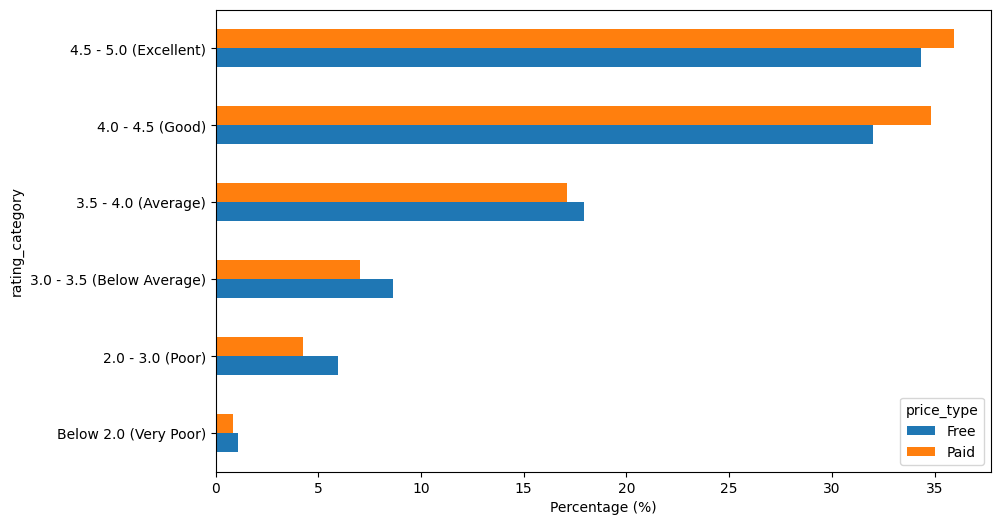

In [ ]:
# Spark table to Pandas
plot_data = rating_distribution.toPandas()

# Percentage to numeric
plot_data['percentage'] = pd.to_numeric(plot_data['percentage'])

x = plot_data.pivot(index='rating_category', columns='price_type', values='percentage')

# Ordering the categories logically
ordered_cats = [
        'Below 2.0 (Very Poor)', '2.0 - 3.0 (Poor)', 
        '3.0 - 3.5 (Below Average)', '3.5 - 4.0 (Average)', 
        '4.0 - 4.5 (Good)', '4.5 - 5.0 (Excellent)'
    ]

ax = x.reindex(ordered_cats)

# Plotting    
ax.plot(kind='barh', figsize=(10, 6))
plt.xlabel("Percentage (%)")
plt.show()

## Data analysis of how the amounts of installations vary between free vs. paid applications

In [34]:
from pyspark.sql.functions import col, round as spark_round, avg, count

# Choosing the needed columns and renaming them
install_comparison = df.select(
    col("pricing.is_free").alias("is_free"),
    col("popularity_metrics.installs").alias("installs")
).groupBy("is_free").agg(
    spark_round(avg("installs"), 0).alias("avg_installs"),
    count("*").alias("app_count")
)

print("Comparison between installations (Free vs. Paid):")
install_comparison.show()

Comparison between installations (Free vs. Paid):
+-------+------------+---------+
|is_free|avg_installs|app_count|
+-------+------------+---------+
|   true|    186403.0|  2261591|
|  false|      8889.0|    44655|
+-------+------------+---------+



In [ ]:
from pyspark.sql.functions import sum as spark_sum

# Calculating total installations per type
total_installs_df = install_comparison.withColumn(
    "total_volume", col("avg_installs") * col("app_count")
)

# Calculating the sum of all installations for percentage calculation
grand_total = total_installs_df.select(spark_sum("total_volume")).collect()[0][0]

# Calculating percentage
final_stat = total_installs_df.withColumn(
    "install_share_percent", spark_round((col("total_volume") / grand_total) * 100, 2)
).withColumn(
    "count_share_percent", spark_round((col("app_count") / (2261591 + 44655)) * 100, 2)
)

final_stat.show()

+-------+------------+---------+----------------+---------------------+-------------------+
|is_free|avg_installs|app_count|    total_volume|install_share_percent|count_share_percent|
+-------+------------+---------+----------------+---------------------+-------------------+
|   true|    186403.0|  2261591|4.21567347173E11|                99.91|              98.06|
|  false|      8889.0|    44655|    3.96938295E8|                 0.09|               1.94|
+-------+------------+---------+----------------+---------------------+-------------------+



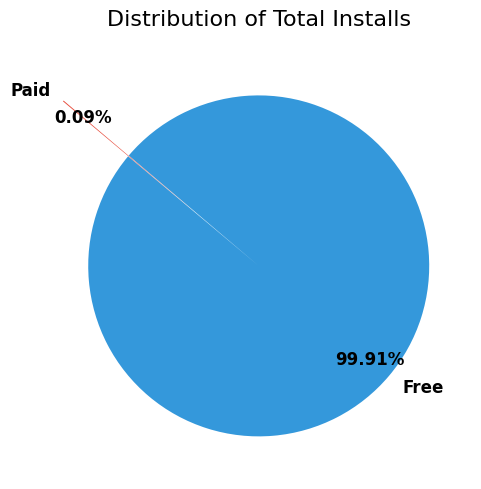

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from results
labels = ['Free', 'Paid']
sizes = [99.91, 0.09]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.5)

# Creating pie chart
fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

ax.set_title('Distribution of Total Installs', fontsize=16, pad=20)

plt.tight_layout()

#### While paid applications represent only a small fraction of the dataset (1,94%), the sample size of 44,655 is still statistically significant. When installation count is related to application count, they cover only 0,09 % of all installations. This suggests that paid applications have a barrier for extensive popularity.

## Depency analysis of advertisements affecting ratings

In [ ]:
df.createOrReplaceTempView("apps_table")

# sql query
sql_results_ads = spark.sql("""
    SELECT 
        features.ads_supported, 
        ROUND(AVG(popularity_metrics.rating), 2) AS avg_rating, 
        COUNT(*) AS app_count
    FROM apps_table
    GROUP BY features.ads_supported
""")

print("Results using Spark SQL:")
sql_results_ads.show()

Results using Spark SQL:
+-------------+----------+---------+
|ads_supported|avg_rating|app_count|
+-------------+----------+---------+
|         true|      4.12|  1148642|
|        false|      4.07|  1157604|
+-------------+----------+---------+



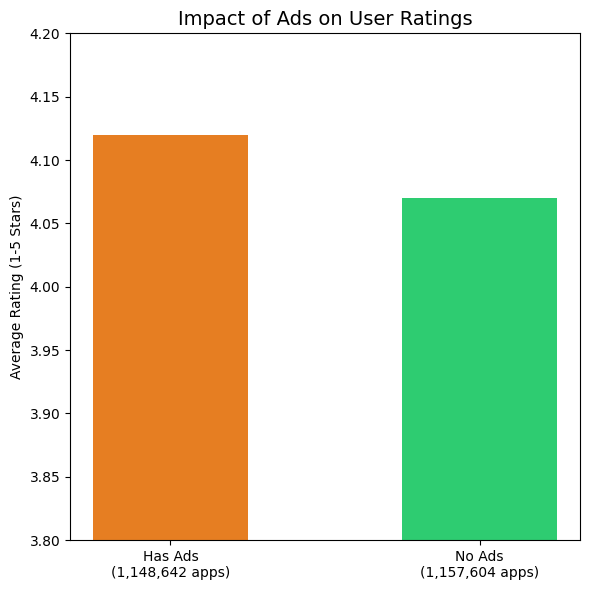

In [ ]:
# Data from Spark results
ad_data = pd.DataFrame({
    'Ad Supported': ['Has Ads\n(1,148,642 apps)', 'No Ads\n(1,157,604 apps)'],
    'Avg Rating': [4.12, 4.07]
})

# Creating plot
plt.figure(figsize=(6, 6))
bars = plt.bar(ad_data['Ad Supported'], ad_data['Avg Rating'], color=['#e67e22', '#2ecc71'], width=0.5)

plt.ylim(3.8, 4.2)
plt.title('Impact of Ads on User Ratings', fontsize=14)
plt.ylabel('Average Rating (1-5 Stars)')

plt.tight_layout()
plt.show()

#### Analysis show a surprising result: Ad-supported applications maintain a higher average rating than those without ads (0.5 difference). This insight may indicate that developers are enabled to provide better maintance and more frequent updates.